# 07 — Van't Hoff diagnostics

Why does Bc help on temperature extrapolation, and what causes failure under
chemistry shift?


## 1. Goal

Three questions:

1. Is the Van't Hoff form $\log S = a + b\cdot z$, with $z = 1/T_\text{ref} - 1/T$,
   a good empirical description of how solubility varies with temperature in this
   dataset?
2. Does Bc actually recover the temperature slope better than the stock B model?
3. Under chemistry shift (cold-solute), is prediction error dominated by the
   intercept $a$ or by the temperature slope $b$?

Everything below uses the predictions already saved in `results/preds/` by
notebook 06. Nothing is retrained.


## 2. Load data and predictions

Standard load. `df_all` is the whole 100,983-row dataset; `preds` is a tidy
concatenation of all 60 saved prediction files.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

ROOT  = Path.cwd().parent
RES   = ROOT / "results"
PREDS = RES / "preds"

features = np.load(RES / "features.npz", allow_pickle=True)
T       = features["T"].astype(np.float64)
y       = features["y"].astype(np.float64)
pair_id = features["pair_id"].astype(np.int64)

splits = np.load(RES / "splits.npz")

with open(RES / "b_scale.json") as fh:
    b_scale_meta = json.load(fh)

SPLITS   = ["random", "textrap", "coldsol", "coldpair", "coldsolv"]
b_scales = {s: b_scale_meta["splits"][s]["b_scale"] for s in SPLITS}
T_REF    = b_scale_meta["meta"]["T_ref_K"]
z_all    = 1.0 / T_REF - 1.0 / T

df_all = pd.DataFrame({"pair_id": pair_id, "T": T, "z": z_all, "y": y})

print(f"rows: {len(df_all):,}   unique pairs: {df_all['pair_id'].nunique():,}")
print(f"T range: {T.min():.1f} - {T.max():.1f} K   T_ref = {T_REF} K")
print(f"|z| median: {np.median(np.abs(z_all)):.3e}   |z| max: {np.abs(z_all).max():.3e}")


rows: 100,983   unique pairs: 10,855
T range: 243.1 - 425.8 K   T_ref = 298.15 K
|z| median: 1.164e-04   |z| max: 1.005e-03


In [2]:
rows = []
for f in sorted(PREDS.glob("preds_*.npz")):
    d = np.load(f, allow_pickle=True)
    row = pd.DataFrame({
        "model":    str(d["model"]),
        "split":    str(d["split"]),
        "seed":     int(d["seed"]),
        "test_idx": d["test_idx"],
        "pair_id":  d["pair_id"],
        "T":        d["T"].astype(np.float64),
        "y_true":   d["y_true"].astype(np.float64),
        "y_pred":   d["y_pred"].astype(np.float64),
    })
    if "slope_a" in d.files:
        row["slope_a"] = d["slope_a"].astype(np.float64)
        row["slope_b"] = d["slope_b"].astype(np.float64)
    else:
        row["slope_a"] = np.nan
        row["slope_b"] = np.nan
    rows.append(row)

preds = pd.concat(rows, ignore_index=True)
preds["z"]   = 1.0 / T_REF - 1.0 / preds["T"]
preds["err"] = preds["y_pred"] - preds["y_true"]

print(f"prediction rows loaded: {len(preds):,}")
preds.groupby(["model", "split"]).size().unstack("split")


prediction rows loaded: 815,532


split,coldpair,coldsol,coldsolv,random,textrap
model,,,,,
A,29970,31308,35220,30297,77088
B,29970,31308,35220,30297,77088
Bc,29970,31308,35220,30297,77088
D,29970,31308,35220,30297,77088


## 3. Empirical per-pair Van't Hoff fits

For each solute-solvent pair with at least 3 distinct temperatures in the full
dataset, fit $\log S = a + b \cdot z$ by ordinary least squares. This is the
empirical description question: how well does a straight line in $z$ fit real
data at the pair level?


In [3]:
MIN_DISTINCT_T = 3

fits = []
for pid, g in df_all.groupby("pair_id"):
    if g["T"].nunique() < MIN_DISTINCT_T:
        continue
    zg = g["z"].values
    yg = g["y"].values
    zc = zg - zg.mean()
    yc = yg - yg.mean()
    denom = float(np.dot(zc, zc))
    if denom == 0:
        continue
    b = float(np.dot(zc, yc) / denom)
    a = float(yg.mean() - b * zg.mean())
    yhat = a + b * zg
    ss_res = float(np.sum((yg - yhat) ** 2))
    ss_tot = float(np.sum((yg - yg.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    resid_rmse = float(np.sqrt(ss_res / len(yg)))
    fits.append({"pair_id": int(pid), "a": a, "b": b, "R2": r2,
                 "resid_rmse": resid_rmse,
                 "n_T": int(g["T"].nunique()),
                 "n_rows": int(len(g))})

vh_fits = pd.DataFrame(fits)
print(f"pairs fitted (>= {MIN_DISTINCT_T} distinct T): {len(vh_fits):,}")
print(f"median R^2:              {vh_fits['R2'].median():.4f}")
print(f"median residual RMSE:    {vh_fits['resid_rmse'].median():.4f} log S")
print(f"median b:                {vh_fits['b'].median():.1f} K")
print(f"median |b|:              {vh_fits['b'].abs().median():.1f} K")


pairs fitted (>= 3 distinct T): 10,500
median R^2:              0.9965
median residual RMSE:    0.0102 log S
median b:                1381.4 K
median |b|:              1381.8 K


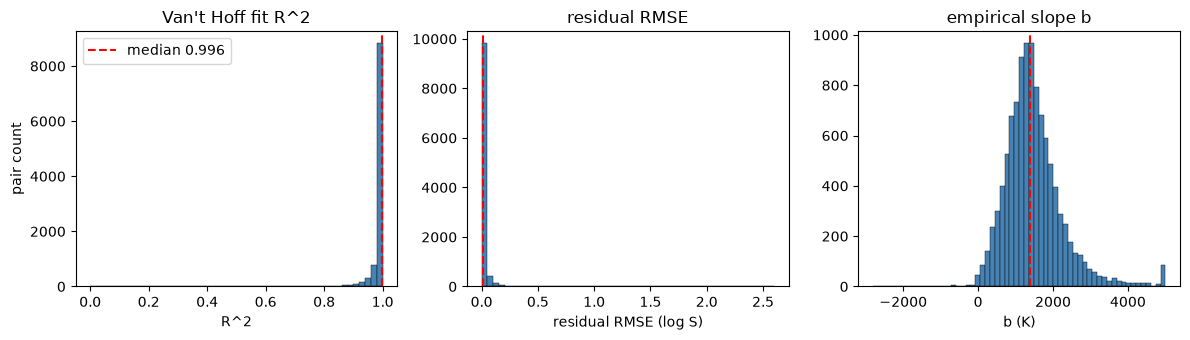

sensitivity (>= 4 distinct T): 10,488 pairs, median R^2 = 0.9965, median |b| = 1381.8 K


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(vh_fits["R2"].clip(0, 1), bins=50, color="steelblue",
             edgecolor="black", linewidth=0.3)
axes[0].axvline(vh_fits["R2"].median(), color="red", linestyle="--",
                label=f"median {vh_fits['R2'].median():.3f}")
axes[0].set_xlabel("R^2"); axes[0].set_ylabel("pair count")
axes[0].set_title("Van't Hoff fit R^2"); axes[0].legend()

axes[1].hist(vh_fits["resid_rmse"], bins=50, color="steelblue",
             edgecolor="black", linewidth=0.3)
axes[1].axvline(vh_fits["resid_rmse"].median(), color="red", linestyle="--")
axes[1].set_xlabel("residual RMSE (log S)"); axes[1].set_title("residual RMSE")

axes[2].hist(vh_fits["b"].clip(-3000, 5000), bins=60,
             color="steelblue", edgecolor="black", linewidth=0.3)
axes[2].axvline(vh_fits["b"].median(), color="red", linestyle="--")
axes[2].set_xlabel("b (K)"); axes[2].set_title("empirical slope b")

plt.tight_layout()
plt.savefig(RES / "fig07_vh_fit_histograms.png", dpi=140, bbox_inches="tight")
plt.show()

vh4 = vh_fits[vh_fits["n_T"] >= 4]
print(f"sensitivity (>= 4 distinct T): {len(vh4):,} pairs, "
      f"median R^2 = {vh4['R2'].median():.4f}, "
      f"median |b| = {vh4['b'].abs().median():.1f} K")


## 4. Van't Hoff oracle

For the T-extrapolation split, fit $(a, b)$ *only on the training rows of each
pair* and predict the held-out (upper-T) rows. Compare against a T-blind
baseline that predicts the pair's training-mean $\log S$. Both baselines require
at least 2 distinct training temperatures for that pair.

The oracle is the best a purely-empirical Van't Hoff model could do if it
knew the true $(a, b)$ of each pair from its training portion. It quantifies
the ceiling of the Van't Hoff structure alone, before any chemistry-transfer.


In [5]:
train_mask = np.zeros(len(y), dtype=bool)
test_mask  = np.zeros(len(y), dtype=bool)
train_mask[splits["textrap_train"]] = True
test_mask[splits["textrap_test"]]  = True

vh_pred     = np.full(len(y), np.nan)
tblind_pred = np.full(len(y), np.nan)

for pid, g in df_all.groupby("pair_id"):
    idx = g.index.values
    tr = idx[train_mask[idx]]
    te = idx[test_mask[idx]]
    if len(te) == 0 or len(tr) < 2:
        continue
    if len(np.unique(T[tr])) < 2:
        continue
    zt = 1.0 / T_REF - 1.0 / T[tr]
    yt = y[tr]
    zc = zt - zt.mean()
    yc = yt - yt.mean()
    denom = float(np.dot(zc, zc))
    if denom == 0:
        continue
    b_hat = float(np.dot(zc, yc) / denom)
    a_hat = float(yt.mean() - b_hat * zt.mean())
    z_te  = 1.0 / T_REF - 1.0 / T[te]
    vh_pred[te]     = a_hat + b_hat * z_te
    tblind_pred[te] = yt.mean()

eligible = ~np.isnan(vh_pred) & test_mask
n_used = int(eligible.sum())

vh_rmse  = float(np.sqrt(np.mean((y[eligible] - vh_pred[eligible]) ** 2)))
tb_rmse  = float(np.sqrt(np.mean((y[eligible] - tblind_pred[eligible]) ** 2)))

print(f"T-extrap oracle (require >= 2 distinct train T per pair):")
print(f"  eligible test rows:     {n_used:,} / {len(splits['textrap_test']):,}")
print(f"  Van't Hoff oracle RMSE: {vh_rmse:.4f} log S")
print(f"  T-blind baseline RMSE:  {tb_rmse:.4f} log S")


T-extrap oracle (require >= 2 distinct train T per pair):
  eligible test rows:     25,674 / 25,696
  Van't Hoff oracle RMSE: 0.1017 log S
  T-blind baseline RMSE:  0.4302 log S


## 5. Learned slope recovery — B vs Bc

Because B and Bc predict $(a, b)$ from descriptors alone, the learned slope is
constant per solute-solvent pair (it does not depend on $T$). For every
prediction row we stored `slope_b` in notebook 06; here we take one value per
pair.

Compare model-implied slope against the empirical OLS slope from section 3.
Uses random-split, seed 42 predictions — the in-distribution setting is the
fair test of "did the model learn the slope at all".


In [6]:
# Per-pair effective slope from B and Bc heads (random split, seed 42).
def per_pair_slope(model_kind, split, seed):
    q = preds.query("model == @model_kind and split == @split and seed == @seed")
    return q.groupby("pair_id")["slope_b"].first()

b_from_B  = per_pair_slope("B",  "random", 42)
b_from_Bc = per_pair_slope("Bc", "random", 42)

b_emp = vh_fits.set_index("pair_id")["b"]

recover = pd.DataFrame({
    "b_empirical": b_emp,
    "b_B":         b_from_B,
    "b_Bc":        b_from_Bc,
}).dropna()

print(f"pairs available for slope recovery: {len(recover):,}\n")
for col, label in [("b_B", "B (stock)"), ("b_Bc", "Bc (conditioned)")]:
    r, _   = pearsonr(recover["b_empirical"], recover[col])
    rho, _ = spearmanr(recover["b_empirical"], recover[col])
    mae    = float((recover["b_empirical"] - recover[col]).abs().mean())
    rmse   = float(np.sqrt(((recover["b_empirical"] - recover[col]) ** 2).mean()))
    print(f"  {label:20s}  Pearson r = {r:.3f}   Spearman rho = {rho:.3f}   "
          f"MAE = {mae:.1f} K   RMSE = {rmse:.1f} K")


pairs available for slope recovery: 6,490



  B (stock)             Pearson r = 0.193   Spearman rho = 0.248   MAE = 607.3 K   RMSE = 932.2 K
  Bc (conditioned)      Pearson r = 0.733   Spearman rho = 0.685   MAE = 385.6 K   RMSE = 613.1 K


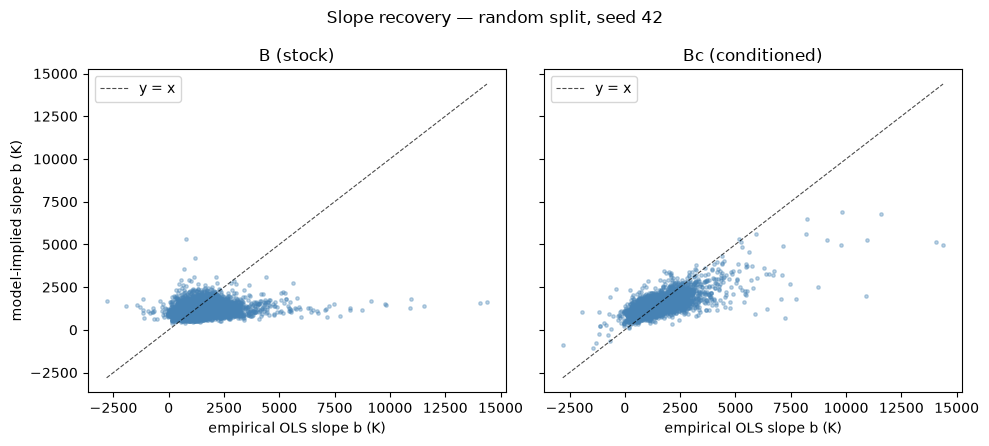

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, col, title in zip(axes, ["b_B", "b_Bc"], ["B (stock)", "Bc (conditioned)"]):
    ax.scatter(recover["b_empirical"], recover[col], s=6, alpha=0.35, color="steelblue")
    lo = min(recover["b_empirical"].min(), recover[col].min())
    hi = max(recover["b_empirical"].max(), recover[col].max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, alpha=0.7, label="y = x")
    ax.set_xlabel("empirical OLS slope b (K)")
    ax.set_title(title)
    ax.legend()
axes[0].set_ylabel("model-implied slope b (K)")
plt.suptitle("Slope recovery — random split, seed 42")
plt.tight_layout()
plt.savefig(RES / "fig07_slope_recovery.png", dpi=140, bbox_inches="tight")
plt.show()


## 6. Conditioning diagnosis — B vs Bc

The gradient argument. With $\log S = a + b \cdot z$ and $|z| \sim 10^{-3}$
across this dataset's temperature range, an MSE loss produces gradients

$$\frac{\partial L}{\partial a} \propto 1 \quad\text{and}\quad
  \frac{\partial L}{\partial b} \propto z.$$

The slope head therefore receives a learning signal that is roughly 1000× smaller
than the intercept head. The Bc reparameterization $b = \beta \cdot b_\text{scale}$
scales $\beta$ by an O(1000) constant so that $\partial L / \partial \beta \propto b_\text{scale} \cdot z$
is O(1) — the two head outputs now compete on comparable footing.


In [8]:
absz = np.abs(z_all)
print("|z| across the dataset:")
print(f"  median:            {np.median(absz):.3e}")
print(f"  p5 / p95:          {np.percentile(absz, 5):.3e}  /  {np.percentile(absz, 95):.3e}")
print(f"  max:               {absz.max():.3e}")
print()
print("Effective slope-head gradient magnitude:")
print(f"  raw parameterization (B):        median |z|            = {np.median(absz):.3e}")
print(f"  reparameterized (Bc), b_scale = {b_scales['random']:.0f}:  b_scale * median |z| = "
      f"{b_scales['random'] * np.median(absz):.3f}")


|z| across the dataset:
  median:            1.164e-04
  p5 / p95:          6.866e-11  /  3.070e-04
  max:               1.005e-03

Effective slope-head gradient magnitude:
  raw parameterization (B):        median |z|            = 1.164e-04
  reparameterized (Bc), b_scale = 1382:  b_scale * median |z| = 0.161


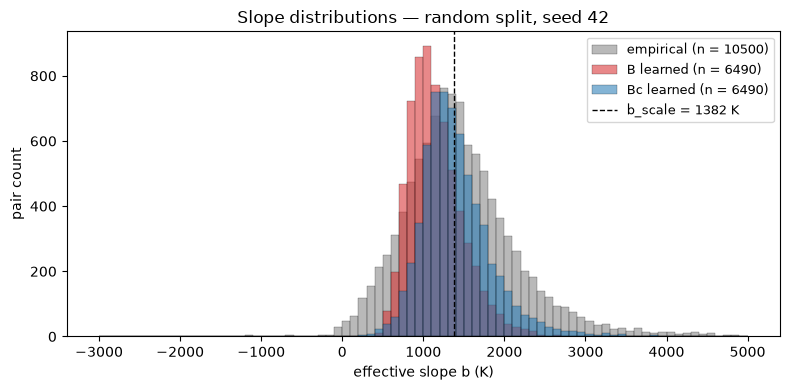

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
kwargs = dict(bins=80, range=(-3000, 5000), alpha=0.55, edgecolor="black", linewidth=0.3)
ax.hist(vh_fits["b"], label=f"empirical (n = {len(vh_fits)})", color="gray", **kwargs)
ax.hist(recover["b_B"],  label=f"B learned (n = {len(recover)})",  color="tab:red",  **kwargs)
ax.hist(recover["b_Bc"], label=f"Bc learned (n = {len(recover)})", color="tab:blue", **kwargs)
ax.axvline(b_scales["random"], color="black", linestyle="--", linewidth=1.0,
           label=f"b_scale = {b_scales['random']:.0f} K")
ax.set_xlabel("effective slope b (K)")
ax.set_ylabel("pair count")
ax.set_title("Slope distributions — random split, seed 42")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RES / "fig07_slope_distributions.png", dpi=140, bbox_inches="tight")
plt.show()


## 7. Paired cluster bootstrap: Bc vs A

For each split, average predictions across the 3 seeds (ensemble) and paired-
bootstrap over pair_id clusters. Repeated measurements from the same pair are
not treated as independent.

Reported per split:
- observed $\Delta \text{RMSE} = \text{RMSE}_{Bc} - \text{RMSE}_A$
  (negative = Bc better),
- 95 % percentile CI over 2000 bootstrap draws,
- fraction of draws with $\Delta < 0$.

The fraction is a bootstrap probability of dominance, not a classical p-value.


In [10]:
N_BOOT = 2000

def cluster_bootstrap(split, model_A="A", model_B="Bc", n_boot=N_BOOT, seed=0):
    a_df = (preds.query("model == @model_A and split == @split")
            .groupby("test_idx")
            .agg(y_true=("y_true","first"),
                 pair_id=("pair_id","first"),
                 y_pred_mean=("y_pred","mean"))
            .reset_index())
    b_df = (preds.query("model == @model_B and split == @split")
            .groupby("test_idx")
            .agg(y_pred_mean=("y_pred","mean"))
            .reset_index())
    df = a_df.merge(b_df, on="test_idx", suffixes=("_A", "_B"))
    df["se_A"] = (df["y_pred_mean_A"] - df["y_true"]) ** 2
    df["se_B"] = (df["y_pred_mean_B"] - df["y_true"]) ** 2

    obs_diff = float(np.sqrt(df["se_B"].mean()) - np.sqrt(df["se_A"].mean()))

    rng = np.random.default_rng(seed)
    pair_list = df["pair_id"].unique()
    pair_to_rows = {p: g.index.values for p, g in df.groupby("pair_id")}

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        picked = rng.choice(pair_list, size=len(pair_list), replace=True)
        rows = np.concatenate([pair_to_rows[p] for p in picked])
        se_A_boot = df["se_A"].values[rows]
        se_B_boot = df["se_B"].values[rows]
        diffs[i]  = np.sqrt(se_B_boot.mean()) - np.sqrt(se_A_boot.mean())

    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    prob_Bc_better = float(np.mean(diffs < 0))
    return {"obs_diff": obs_diff, "ci_lo": float(ci_lo), "ci_hi": float(ci_hi),
            "prob_Bc_better": prob_Bc_better, "n_pairs_test": int(len(pair_list)),
            "n_rows_test": int(len(df))}

boot_rows = []
for s in ["textrap", "coldsol", "coldpair", "coldsolv"]:
    r = cluster_bootstrap(s)
    boot_rows.append({"split": s, **r})
    print(f"{s:9s}   obs Δ = {r['obs_diff']:+.4f}   95% CI = [{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]   "
          f"P(Bc better) = {r['prob_Bc_better']:.3f}   pairs = {r['n_pairs_test']}")

bootstrap_df = pd.DataFrame(boot_rows).set_index("split")
bootstrap_df.to_csv(RES / "bootstrap_bc_vs_a.csv")


textrap     obs Δ = -0.0193   95% CI = [-0.0221, -0.0167]   P(Bc better) = 1.000   pairs = 10301


coldsol     obs Δ = -0.0171   95% CI = [-0.0294, -0.0057]   P(Bc better) = 0.998   pairs = 1067


coldpair    obs Δ = +0.0034   95% CI = [-0.0091, +0.0161]   P(Bc better) = 0.305   pairs = 1085


coldsolv    obs Δ = -0.0228   95% CI = [-0.0346, -0.0118]   P(Bc better) = 1.000   pairs = 1226


## 8. Intercept/slope error decomposition

For Bc, the prediction at any $(x_\text{solute}, x_\text{solvent}, T)$ has the
form $\hat a + \hat b \cdot z$. Given the pair's empirical fit $(a^*, b^*)$
from section 3, the deviation of Bc from the empirical straight line
decomposes exactly as:

$$\hat y - (a^* + b^* z) = \underbrace{(\hat a - a^*)}_{\text{intercept error } da}
 + \underbrace{(\hat b - b^*)}_{\text{slope error } db} \cdot z.$$

Compute this on the cold-solute and T-extrap test rows (seed 42). Hypothesis:
under cold-solute, $|da|$ dominates $|db \cdot z|$, meaning the model gets
the *shape* of the curve roughly right but misplaces it vertically for unseen
chemistry.


In [11]:
def decompose(split, seed=42):
    q = preds.query("model == 'Bc' and split == @split and seed == @seed")[
        ["pair_id", "T", "z", "y_true", "y_pred", "slope_a", "slope_b"]
    ].copy()
    a_pred_pp = q.groupby("pair_id")["slope_a"].first()
    b_pred_pp = q.groupby("pair_id")["slope_b"].first()
    a_true_pp = vh_fits.set_index("pair_id")["a"]
    b_true_pp = vh_fits.set_index("pair_id")["b"]

    q["a_pred"] = q["pair_id"].map(a_pred_pp)
    q["b_pred"] = q["pair_id"].map(b_pred_pp)
    q["a_true"] = q["pair_id"].map(a_true_pp)
    q["b_true"] = q["pair_id"].map(b_true_pp)
    q = q.dropna(subset=["a_true", "b_true"]).copy()

    q["da"] = q["a_pred"] - q["a_true"]
    q["db"] = q["b_pred"] - q["b_true"]
    q["intercept_contrib"] = q["da"].abs()
    q["slope_contrib"]     = (q["db"] * q["z"]).abs()

    # Identity check: y_pred - (a_true + b_true * z) == da + db * z.
    q["identity_diff"] = ((q["da"] + q["db"] * q["z"])
                          - (q["y_pred"] - (q["a_true"] + q["b_true"] * q["z"]))).abs()
    return q

for s in ["textrap", "coldsol"]:
    d = decompose(s)
    print(f"--- {s} ---")
    print(f"  eligible rows:                       {len(d):,}")
    print(f"  identity check max |diff|:           {d['identity_diff'].max():.2e}")
    print(f"  median |intercept contribution| :    {d['intercept_contrib'].median():.4f} log S")
    print(f"  median |slope contribution| (|db*z|):{d['slope_contrib'].median():.4f} log S")
    print(f"  ratio intercept / slope:             "
          f"{d['intercept_contrib'].median() / d['slope_contrib'].median():.2f}x")
    print()


--- textrap ---
  eligible rows:                       25,696
  identity check max |diff|:           6.78e-07
  median |intercept contribution| :    0.0831 log S
  median |slope contribution| (|db*z|):0.0643 log S
  ratio intercept / slope:             1.29x

--- coldsol ---
  eligible rows:                       10,423
  identity check max |diff|:           7.56e-07
  median |intercept contribution| :    0.5266 log S
  median |slope contribution| (|db*z|):0.0383 log S
  ratio intercept / slope:             13.74x



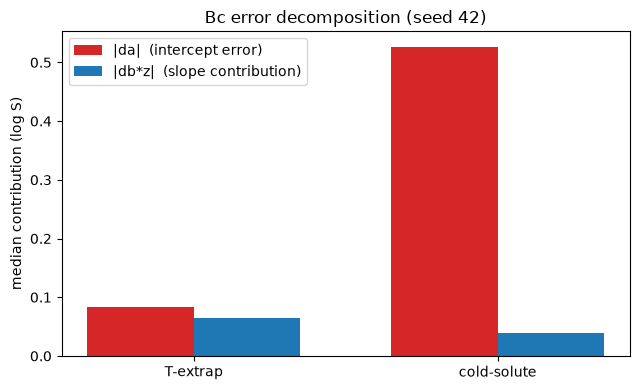

In [12]:
d_textrap = decompose("textrap")
d_coldsol = decompose("coldsol")

fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ["T-extrap", "cold-solute"]
inter = [d_textrap["intercept_contrib"].median(),
         d_coldsol["intercept_contrib"].median()]
slope = [d_textrap["slope_contrib"].median(),
         d_coldsol["slope_contrib"].median()]
x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, inter, w, label="|da|  (intercept error)",  color="tab:red")
ax.bar(x + w/2, slope, w, label="|db*z|  (slope contribution)", color="tab:blue")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("median contribution (log S)")
ax.set_title("Bc error decomposition (seed 42)")
ax.legend()
plt.tight_layout()
plt.savefig(RES / "fig07_error_decomposition.png", dpi=140, bbox_inches="tight")
plt.show()


## 9. Conclusions

Answers to the three opening questions, filled from the numbers computed above.


In [13]:
def _label_bootstrap(row):
    if row["ci_hi"] < 0:
        return "Bc statistically better (95% CI excludes 0)"
    if row["ci_lo"] > 0:
        return "Bc statistically worse (95% CI excludes 0)"
    return "no significant difference (95% CI includes 0)"

vh_r2 = vh_fits["R2"].median()
vh_resid = vh_fits["resid_rmse"].median()
r_B_val,  _ = pearsonr(recover["b_empirical"], recover["b_B"])
r_Bc_val, _ = pearsonr(recover["b_empirical"], recover["b_Bc"])
mae_B  = float((recover["b_empirical"] - recover["b_B"]).abs().mean())
mae_Bc = float((recover["b_empirical"] - recover["b_Bc"]).abs().mean())

textrap_boot = bootstrap_df.loc["textrap"]
coldsol_boot = bootstrap_df.loc["coldsol"]

coldsol_ratio = (d_coldsol["intercept_contrib"].median() /
                 d_coldsol["slope_contrib"].median())
textrap_ratio = (d_textrap["intercept_contrib"].median() /
                 d_textrap["slope_contrib"].median())

conclusion = pd.DataFrame([
    {"question": "Is Van't Hoff a good local description?",
     "result": f"median R^2 = {vh_r2:.3f}, residual RMSE = {vh_resid:.3f} log S over "
               f"{len(vh_fits):,} pairs (>=3 distinct T)"},
    {"question": "Does Bc recover slope better than B?",
     "result": f"Pearson r: B = {r_B_val:.3f}, Bc = {r_Bc_val:.3f}; "
               f"MAE: B = {mae_B:.0f} K, Bc = {mae_Bc:.0f} K"},
    {"question": "Does Bc help T-extrap? (bootstrap)",
     "result": f"Δ = {textrap_boot['obs_diff']:+.4f}, "
               f"95% CI [{textrap_boot['ci_lo']:+.4f}, {textrap_boot['ci_hi']:+.4f}]  →  "
               + _label_bootstrap(textrap_boot)},
    {"question": "Does Bc help cold-solute? (bootstrap)",
     "result": f"Δ = {coldsol_boot['obs_diff']:+.4f}, "
               f"95% CI [{coldsol_boot['ci_lo']:+.4f}, {coldsol_boot['ci_hi']:+.4f}]  →  "
               + _label_bootstrap(coldsol_boot)},
    {"question": "What dominates cold-solute Bc error?",
     "result": f"intercept |da| dominates slope |db*z| by {coldsol_ratio:.1f}x "
               f"(T-extrap ratio = {textrap_ratio:.1f}x for comparison)"},
])
conclusion


,question,result
0,Is Van't Hoff a good local description?,"median R^2 = 0.996, residual RMSE = 0.010 log ..."
1,Does Bc recover slope better than B?,"Pearson r: B = 0.193, Bc = 0.733; MAE: B = 607..."
2,Does Bc help T-extrap? (bootstrap),"Δ = -0.0193, 95% CI [-0.0221, -0.0167] → Bc ..."
3,Does Bc help cold-solute? (bootstrap),"Δ = -0.0171, 95% CI [-0.0294, -0.0057] → Bc ..."
4,What dominates cold-solute Bc error?,intercept |da| dominates slope |db*z| by 13.7x...
